<a href="https://colab.research.google.com/github/mampu092/MNIST_Dataset_comparing_ann-model-deep_ann-model-_cnn/blob/main/MNIST_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
x_train_ann = x_train
x_test_ann = x_test

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

ann_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.fit(x_train, y_train, epochs=5)
loss, accuracy = ann_model.evaluate(x_test, y_test)

print("\nTest Accuracy:", accuracy)
print("Test Loss:", loss)

y_pred = ann_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_classes))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8866 - loss: 0.4115
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9653 - loss: 0.1165
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9767 - loss: 0.0765
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9848 - loss: 0.0517
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9881 - loss: 0.0391
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9740 - loss: 0.0790

Test Accuracy: 0.9764999747276306
Test Loss: 0.07204342633485794
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.98      0.98      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.99      0.

[[ 967    0    3    3    0    0    3    0    3    1]
 [   0 1113    3    3    0    0    2    1   13    0]
 [   1    3 1006    3    1    0    2    7    9    0]
 [   0    0    3  991    0    1    0    5    6    4]
 [   0    0    4    0  970    0    3    1    0    4]
 [   2    0    0   18    2  855    5    1    9    0]
 [   1    3    2    1    3    4  939    0    5    0]
 [   2    3    8    3    3    0    0 1000    3    6]
 [   1    0    5    5    2    0    1    3  954    3]
 [   1    3    0    8   16    1    1    5    4  970]]


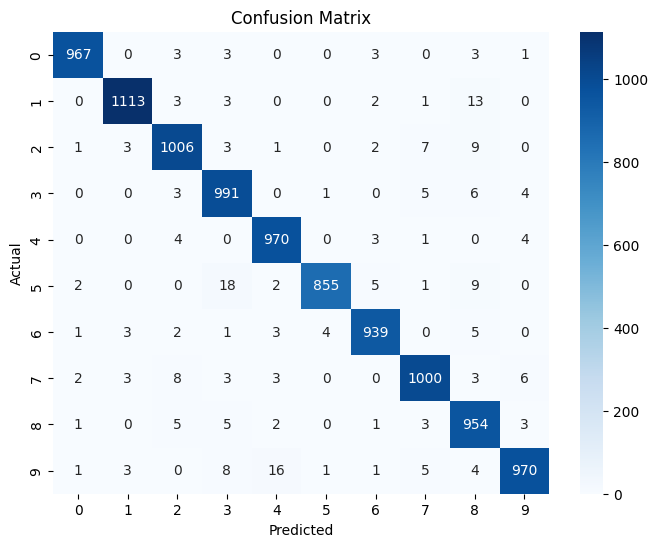

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

deep_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.fit(x_train, y_train, epochs=5, batch_size=128)
loss, accuracy = deep_model.evaluate(x_test, y_test)

print("\nTest Accuracy:", accuracy)
print("Test Loss:", loss)

y_pred = deep_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_classes))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8488 - loss: 0.5314
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9691 - loss: 0.1041
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9800 - loss: 0.0679
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9852 - loss: 0.0484
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9898 - loss: 0.0322
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9720 - loss: 0.0925

Test Accuracy: 0.9768999814987183
Test Loss: 0.07933241873979568
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.95      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      

[[ 974    1    0    0    0    0    3    1    1    0]
 [   0 1123    3    2    1    0    2    2    2    0]
 [   7    0 1005    3    3    0    2   11    1    0]
 [   0    0    4  997    0    2    0    5    2    0]
 [   2    0    1    1  962    0    4    4    1    7]
 [   2    1    0    9    1  868    6    0    4    1]
 [   4    3    0    0    2    4  943    0    2    0]
 [   2    3    4    2    2    0    1 1011    1    2]
 [   6    0    4   16    3    2    3    3  932    5]
 [   7    2    0   19    7    5    2   11    2  954]]


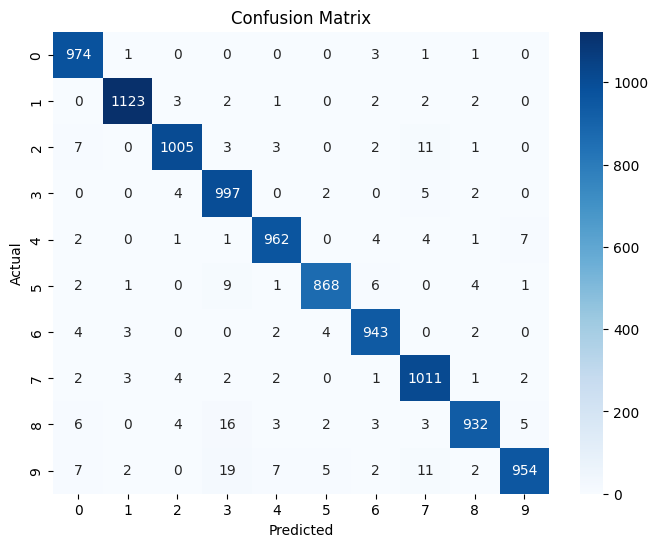

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.datasets import mnist
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.fit(x_train, y_train, epochs=5, batch_size=128)
loss, accuracy = cnn_model.evaluate(x_test, y_test)

print("\nTest Accuracy:", accuracy)
print("Test Loss:", loss)
y_pred = cnn_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_classes))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 111ms/step - accuracy: 0.8689 - loss: 0.4710
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - accuracy: 0.9820 - loss: 0.0581
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 111ms/step - accuracy: 0.9886 - loss: 0.0374
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - accuracy: 0.9913 - loss: 0.0287
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - accuracy: 0.9932 - loss: 0.0217
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9872 - loss: 0.0366

Test Accuracy: 0.9904999732971191
Test Loss: 0.028920287266373634
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99  

[[ 975    0    1    0    0    0    2    1    1    0]
 [   0 1126    2    0    1    0    1    2    3    0]
 [   0    0 1024    0    1    0    0    6    1    0]
 [   0    0    2 1002    0    1    0    1    4    0]
 [   0    0    0    0  977    0    0    0    0    5]
 [   2    0    0    9    0  876    1    1    2    1]
 [   5    2    0    0    6    5  938    0    2    0]
 [   0    1    4    1    0    0    0 1020    0    2]
 [   0    0    2    1    2    0    0    0  967    2]
 [   0    0    0    0    3    2    0    2    2 1000]]


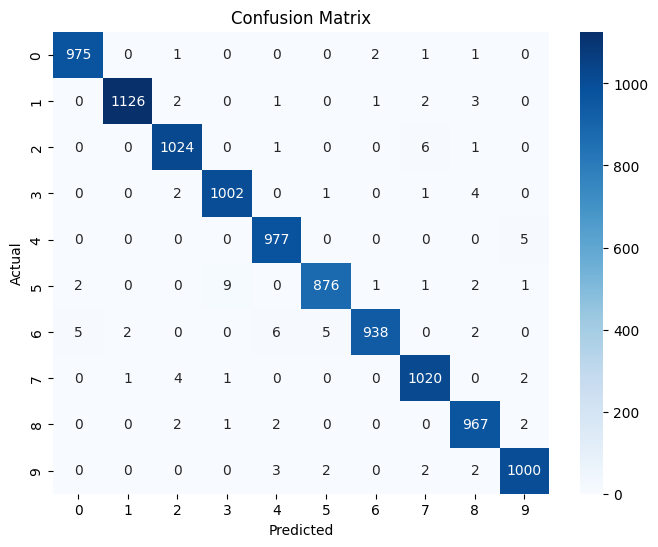

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
results = []

def evaluate_model(model, name, x_data):
    loss, accuracy = model.evaluate(x_data, y_test, verbose=0)
    results.append((name, accuracy, loss))
    print(f"{name} → Accuracy: {accuracy:.4f}, Loss: {loss:.4f}")
evaluate_model(ann_model, "Single Hidden Layer BPN", x_test_ann)
evaluate_model(deep_model, "Multi Hidden Layer BPN", x_test_ann)
evaluate_model(cnn_model, "CNN", x_test_cnn)

Single Hidden Layer BPN → Accuracy: 0.9765, Loss: 0.0720
Multi Hidden Layer BPN → Accuracy: 0.9769, Loss: 0.0793
CNN → Accuracy: 0.9905, Loss: 0.0289


In [ ]:
print("\nModel Comparison:")
for r in results:
    print(r)


Model Comparison:
('Single Hidden Layer BPN', 0.9764999747276306, 0.07204342633485794)
('Multi Hidden Layer BPN', 0.9768999814987183, 0.07933241873979568)
('CNN', 0.9904999732971191, 0.028920287266373634)
